In [6]:
# Import Pandas for data manipulation and analysis.
import pandas as pd

# Import Matplotlib for creating data visualizations and plots.
import matplotlib.pyplot as plt

# Import train_test_split to divide the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

# Import DecisionTreeClassifier to build a decision tree classification model.
# Import plot_tree to visualize the structure of the decision tree.
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Import metrics to evaluate the performance of the classification model.
# accuracy_score calculates the overall accuracy.
# confusion_matrix shows correct and incorrect predictions for each class.
# classification_report provides precision, recall, F1-score, and support.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
# -----------------------------------------------------------------------------
# Load the Real-World Dataset
# ----------------------------------------------------------------------------- 

# Load the dataset from a CSV file into a Pandas DataFrame.
df = pd.read_csv("assets/titanic_passengers_dataset.csv")

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

In [9]:
# -----------------------------------------------------------------------------
# Data Pre-Processing - I
# -----------------------------------------------------------------------------

# Real-world data can contain irrelevant and unnecessary informations.
# Select only the features that are relevant for predicting titanic passengers survival.

# Keep the selected features and create a copy of the DataFrame for cleaning.
cols_to_keep = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']
df_clean = df[cols_to_keep].copy()

# Display information about the selected dataset, including data types and missing values.
print(df_clean.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    str    
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    str    
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None


In [10]:
# -----------------------------------------------------------------------------
# Data Pre-Processing II - Handling Missing Values
# -----------------------------------------------------------------------------

# Handle missing values in the dataset.
# Replace missing Age values with the median age of the passengers.
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)

# Replace missing Embarked values with the most frequently occurring port (mode).
most_common_port = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(most_common_port)

# Display the dataset information after handling the missing values.
print("After handling missing values:")
print(df_clean.info())


After handling missing values:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    str    
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    str    
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None


In [11]:
# -----------------------------------------------------------------------------
# Separate Features and Target Variable
# -----------------------------------------------------------------------------

# Separate the input features (x) from the target variable (y).
# The 'Survived' column is the target variable that the model will predict.
x_raw = df_clean.drop('Survived', axis=1)
# The output is a binary classification (0 = Died, 1 = Survived)
y = df_clean['Survived']

# Display the first five rows of the input features.
print(x_raw.head())

# Display the first five values of the target variable.
print(y.head())

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [12]:
# -----------------------------------------------------------------------------
# Data Pre-processing III - One-Hot Encoding
# -----------------------------------------------------------------------------

# Convert categorical features into numerical columns using one-hot encoding.
# Convert 'Sex (Male/Female)' and 'Embarked (Q/S/C)' into binary columns.
# This allows the machine learning model to work with categorical data.
# drop_first=True removes one category from each feature to avoid redundancy.
x = pd.get_dummies(x_raw, columns=['Sex', 'Embarked'], drop_first=True)

# Display the first five rows of the one-hot encoded features.
print("First 5 rows of the one-hot encoded features:")
print(x.head())

First 5 rows of the one-hot encoded features:
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True


In [13]:
# -----------------------------------------------------------------------------
# Split the Dataset into Training and Testing Sets
# -----------------------------------------------------------------------------

# Split the dataset into training and testing sets, with 80% of the data used for training and 20% for testing.
# The random_state parameter with value 42 ensures reproducibility of the split.
# 42 means that the random number generator will produce the same results each time the code is run.
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Display the number of rows and columns in the training and testing datasets.
print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}, Y_test shape: {Y_test.shape}")

X_train shape: (712, 8), Y_train shape: (712,)
X_test shape: (179, 8), Y_test shape: (179,)


In [14]:
# -----------------------------------------------------------------------------
# Create and Train the Decision Tree Classifier
# -----------------------------------------------------------------------------

# Create a Decision Tree classification model.
# criterion="gini" uses Gini Impurity to determine the quality of each split.
# max_depth=5 limits the maximum depth of the tree to reduce overfitting.
# random_state=42 ensures that the model produces reproducible results.
clf = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)

# Train the Decision Tree model using the training features and target values.
# The model learns decision rules from the training data to classify passengers.
clf.fit(X_train, Y_train)

# Display the depth of the trained Decision Tree.
print("Tree Depth:", clf.get_depth())

# Display the total number of nodes in the trained Decision Tree.
print("Number of Nodes:", clf.tree_.node_count)

Tree Depth: 5
Number of Nodes: 47


In [16]:
# -----------------------------------------------------------------------------
# Evaluate the Decision Tree Classifier Model
# -----------------------------------------------------------------------------

# Use the trained model to predict the target values for the testing dataset.
Y_predict = clf.predict(X_test)

# Calculate and display the accuracy of the model.
# Accuracy represents the proportion of correct predictions made by the model.
accuracy = accuracy_score(Y_test, Y_predict)
print(f"Model Accuracy: {accuracy:.2f}")

# Generate and display the Confusion Matrix.
# It shows the number of correct and incorrect predictions for each class.
# Shows     [True Positives, False Negatives] 
#           [False Positives, True Negatives]
conf_matrix = confusion_matrix(Y_test, Y_predict)
print("Confusion Matrix:")
print(conf_matrix)

# Generate and display the Classification Report.
# It provides precision, recall, F1-score, and support for each class.
class_report = classification_report(Y_test, Y_predict)
print("Classification Report:")
print(class_report)

Model Accuracy: 0.80
Confusion Matrix:
[[95 10]
 [26 48]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



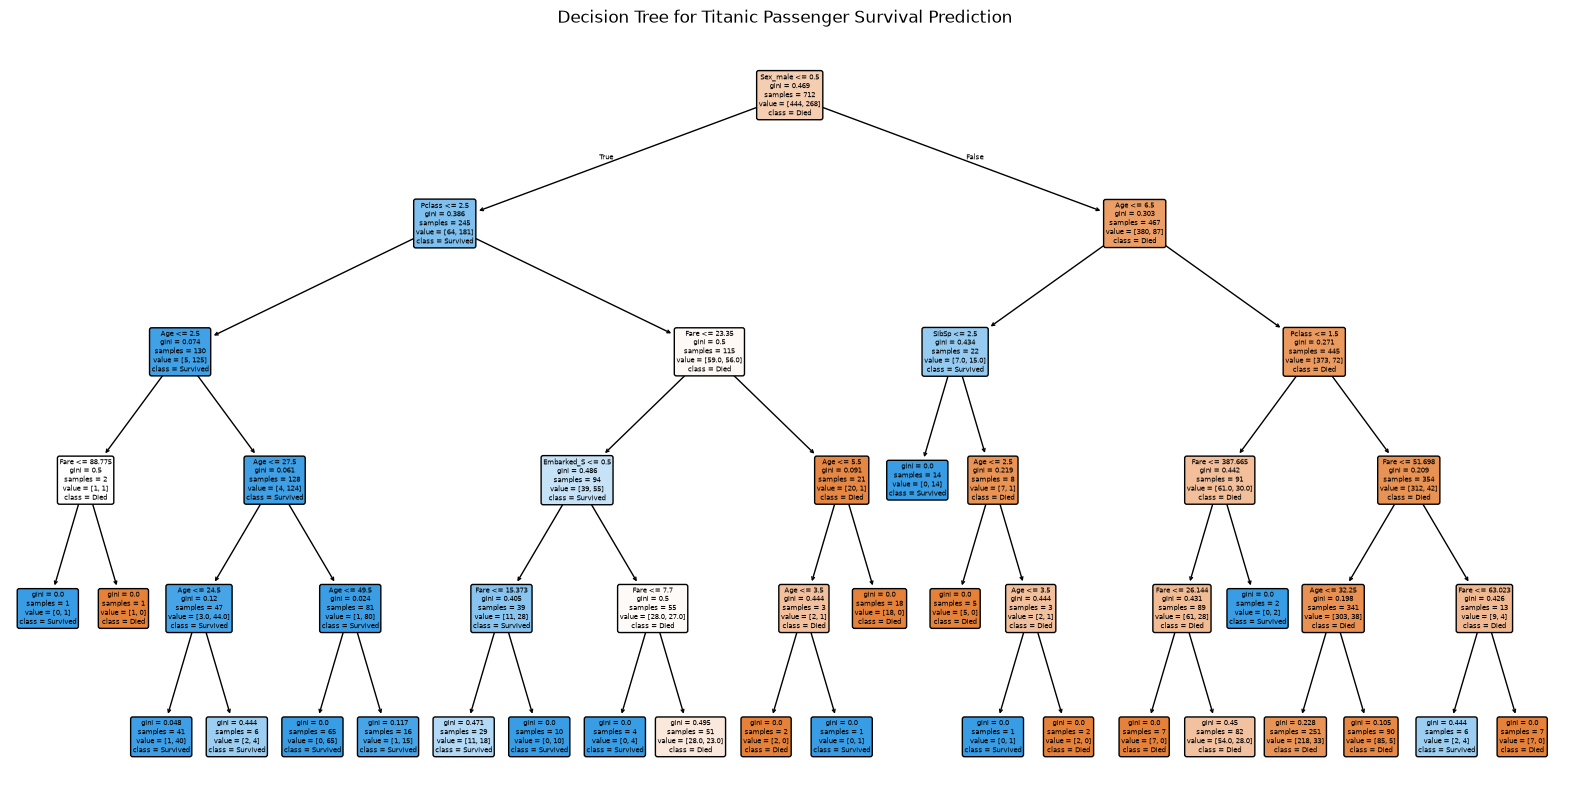

In [21]:
# -----------------------------------------------------------------------------
# Visualize the Decision Tree
# -----------------------------------------------------------------------------

# Create a figure to display the Decision Tree.
# figsize=(20, 10) sets the width and height of the figure in inches.
plt.figure(figsize=(20, 10))

# Draw the trained Decision Tree.
# feature_names displays the actual feature names in the tree.
# class_names displays the possible classes at the leaf nodes.
# filled=True fills the nodes with colors to make the tree easier to interpret.
# rounded=True displays the decision nodes with rounded corners.
plot_tree(
    clf,
    feature_names=list(x.columns),
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True
)

# Add a title to the Decision Tree visualization.
plt.title("Decision Tree for Titanic Passenger Survival Prediction")

# Display the completed Decision Tree visualization.
plt.show()

In [22]:
# -----------------------------------------------------------------------------
# Predict an Unknown Data Sample (Jack Dawson and Rose DeWitt Bukater)
# -----------------------------------------------------------------------------

# Scenario 1: Jack Dawson (from the movie).
# Class: 3 (Poor), Age:20, Siblings: 0, Parents: 0, Fare: 7.25, Sex: Male, Embarked: S
print("Predicting survival for Jack Dawson:")

# We must create a new row with the EXACT same columns as the training data (X)
# 1. Create a zero filled dictionary for all columns.
jack_data = {col: 0 for col in x.columns}

# 2. Fill in Jack's details.
jack_data["Pclass"] = 3
jack_data["Age"] = 20
jack_data["SibSp"] = 0
jack_data["Parch"] = 0
jack_data["Fare"] = 7.25
# For One-Hot Encoded columns, we set the specific bit to 1.
# Note: "Sex_male" exists because we dropped "Sex_female"
# If "Sex_male" is 1, he is Male
jack_data["Sex_male"] = 1
# Embarked "S" is ususally the baseline (all Embarked cols 0), but let's check columns.
if "Embarked_S" in x.columns:
    jack_data["Embarked_S"] = 1
# Note: In "drop_first=True", usually one category is dropped, S id often dropped or kept depending on the dataset. 
# If "Embarked_C" or "Embarked_Q" exist, we set them to 0.
if "Embarked_C" in x.columns:
    jack_data["Embarked_C"] = 0
if "Embarked_Q" in x.columns:
    jack_data["Embarked_Q"] = 0

# 3. Convert to DataFrame.
jack_df = pd.DataFrame([jack_data])
print(jack_df)

# 4. Predict survival using the trained Decision Tree model.
jack_prediction = clf.predict(jack_df)[0]
jack_probability = clf.predict_proba(jack_df)[0]

jack_outcome = "Survived" if jack_prediction == 1 else "Died"
print(f"Prediction: Jack Dawson would have {jack_outcome}.")
print(f"Confidence: Died: {jack_probability[0]:.2f}, Survived: {jack_probability[1]:.2f}")

# Scenario 2: Rose DeWitt Bukater (from the movie).
print("\nPredicting survival for Rose DeWitt Bukater:")
rose_df = pd.DataFrame([{
    "Pclass": 1,
    "Age": 17,
    "SibSp": 0,
    "Parch": 2,
    "Fare": 700.0,
    "Sex_male": 0,  
    "Embarked_Q": 0,
    "Embarked_S": 1
    }])
print(rose_df)

rose_prediction = clf.predict(rose_df)[0]
rose_probability = clf.predict_proba(rose_df)[0]

rose_outcome = "Survived" if rose_prediction == 1 else "Died"
print(f"Prediction: Rose DeWitt Bukater would have {rose_outcome}.")
print(f"Confidence: Died: {rose_probability[0]:.2f}, Survived: {rose_probability[1]:.2f}")


Predicting survival for Jack Dawson:
   Pclass  Age  SibSp  Parch  Fare  Sex_male  Embarked_Q  Embarked_S
0       3   20      0      0  7.25         1           0           1
Prediction: Jack Dawson would have Died.
Confidence: Died: 0.87, Survived: 0.13

Predicting survival for Rose DeWitt Bukater:
   Pclass  Age  SibSp  Parch   Fare  Sex_male  Embarked_Q  Embarked_S
0       1   17      0      2  700.0         0           0           1
Prediction: Rose DeWitt Bukater would have Survived.
Confidence: Died: 0.02, Survived: 0.98
